In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

/home/hansennie/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# 手搓多元线性回归 + 正则化 — 加州房价预测
## 1. 加载与预处理数据

In [2]:
# 直接从CSV文件加载加州房价数据
csv_path = 'housing.csv'
df = pd.read_csv(csv_path)

# 删除含有缺失值的行
print(f'原始样本数: {len(df)}')
df = df.dropna()
print(f'清洗后样本数: {len(df)}')

# 创建派生特征 (与 sklearn fetch_california_housing 格式一致)
X = np.column_stack([
    df['median_income'].values,           # MedInc
    df['housing_median_age'].values,      # HouseAge
    df['total_rooms'].values / df['households'].values,   # AveRooms
    df['total_bedrooms'].values / df['households'].values, # AveBedrms
    df['population'].values,              # Population
    df['population'].values / df['households'].values,     # AveOccup
    df['latitude'].values,                # Latitude
    df['longitude'].values,               # Longitude
])

# 目标变量：房价中位数（单位：10万美元）
y = (df['median_house_value'].values / 100000.0).reshape(-1, 1)

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

print(f'数据集大小: {X.shape[0]} 个样本, {X.shape[1]} 个特征')
print(f'特征名: {feature_names}')
print(f'目标变量范围: [{y.min():.4f}, {y.max():.4f}]')
print(f'目标变量均值: {y.mean():.4f}, 标准差: {y.std():.4f}')

原始样本数: 20640
清洗后样本数: 20433
数据集大小: 20433 个样本, 8 个特征
特征名: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标变量范围: [0.1500, 5.0000]
目标变量均值: 2.0686, 标准差: 1.1543


In [3]:
# 注意：正则化不惩罚截距项，但这里为了保持代码结构与无正则化版本一致，
# 仍然使用含偏置列的结构，但在梯度下降时不对偏置项施加惩罚
X_with_bias = np.c_[np.ones((X.shape[0], 1)), X]

scaler = StandardScaler()
X_scaled = X_with_bias.copy()
X_scaled[:, 1:] = scaler.fit_transform(X[:, :])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

训练集: 16346, 测试集: 4087


## 2. 带正则化的多元线性回归类
### 支持 L1 (Lasso) 和 L2 (Ridge) 正则化

In [4]:
class RegularizedLinearRegression:
    """
    手搓带正则化的多元线性回归
    
    支持:
    - L2 正则化 (Ridge): 惩罚项 = lambda * ||theta[1:]||^2
    - L1 正则化 (Lasso): 惩罚项 = lambda * ||theta[1:]||_1
    - ElasticNet: 惩罚项 = lambda * (alpha * L1 + (1-alpha) * L2)
    
    使用梯度下降求解（正则化后的目标函数通常无闭式解，尤其是L1）
    """
    
    def __init__(self, penalty='l2', lam=1.0, alpha=0.5, lr=0.01, max_iter=5000, tol=1e-6):
        """
        Parameters
        ----------
        penalty : str, 'l1'(Lasso), 'l2'(Ridge), 'elasticnet'
        lam : float, 正则化强度
        alpha : float, ElasticNet 中 L1 比例 (0~1)
        lr : float, 学习率
        max_iter : int, 最大迭代次数
        tol : float, 收敛阈值
        """
        self.penalty = penalty
        self.lam = lam
        self.alpha = alpha
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.theta = None
        self.cost_history = []
    
    def _cost(self, X, y):
        """
        带正则化惩罚的代价函数
        J = MSE/2 + lambda * R(theta)
        """
        m = len(y)
        predictions = X @ self.theta
        mse = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
        
        # 不惩罚截距项 theta[0]
        if self.penalty == 'l2':
            reg = self.lam * np.sum(self.theta[1:] ** 2)
        elif self.penalty == 'l1':
            reg = self.lam * np.sum(np.abs(self.theta[1:]))
        elif self.penalty == 'elasticnet':
            l1 = self.alpha * np.sum(np.abs(self.theta[1:]))
            l2 = (1 - self.alpha) * np.sum(self.theta[1:] ** 2)
            reg = self.lam * (l1 + l2)
        else:
            raise ValueError(f"Unknown penalty: {self.penalty}")
        
        return mse + reg
    
    def fit(self, X, y):
        """
        梯度下降训练
        
        L2 梯度: theta_j -= lr * (MSE_grad + 2*lambda*theta_j)  for j>0
        L1 梯度: theta_j -= lr * (MSE_grad + lambda*sign(theta_j))  for j>0 (次梯度)
        """
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.cost_history = []
        
        for i in range(self.max_iter):
            predictions = X @ self.theta
            
            # MSE 梯度
            gradient = (1 / m) * X.T @ (predictions - y)
            
            # 正则化梯度 (仅对非截距项)
            if self.penalty == 'l2':
                gradient[1:] += 2 * self.lam * self.theta[1:]
            elif self.penalty == 'l1':
                gradient[1:] += self.lam * np.sign(self.theta[1:])
            elif self.penalty == 'elasticnet':
                gradient[1:] += self.lam * (
                    self.alpha * np.sign(self.theta[1:]) +
                    2 * (1 - self.alpha) * self.theta[1:]
                )
            
            self.theta -= self.lr * gradient
            
            cost = self._cost(X, y)
            self.cost_history.append(cost)
            
            if i > 0 and abs(self.cost_history[-1] - self.cost_history[-2]) < self.tol:
                print(f'{self.penalty} 在第 {i} 轮收敛')
                break
        
        return self
    
    def predict(self, X):
        return X @ self.theta
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

## 3. 训练 L2 正则化 (Ridge)

In [5]:
# 尝试不同 lambda 值
lam_values = [0.001, 0.01, 0.1, 1.0, 10.0]
ridge_results = {}

for lam in lam_values:
    ridge = RegularizedLinearRegression(penalty='l2', lam=lam, lr=0.01, max_iter=5000)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    ridge_results[lam] = {
        'mse': mean_squared_error(y_test, y_pred_ridge),
        'r2': ridge.score(X_test, y_test),
        'mae': mean_absolute_error(y_test, y_pred_ridge)
    }
    print(f'lambda={lam:.3f}: MSE={ridge_results[lam]["mse"]:.6f}, '
          f'R^2={ridge_results[lam]["r2"]:.4f}, MAE={ridge_results[lam]["mae"]:.4f}')

l2 在第 3034 轮收敛
lambda=0.001: MSE=0.562279, R^2=0.5888, MAE=0.5405


l2 在第 2441 轮收敛
lambda=0.010: MSE=0.564902, R^2=0.5869, MAE=0.5464


l2 在第 837 轮收敛
lambda=0.100: MSE=0.640094, R^2=0.5319, MAE=0.6027
l2 在第 531 轮收敛
lambda=1.000: MSE=0.974034, R^2=0.2877, MAE=0.7784


l2 在第 531 轮收敛
lambda=10.000: MSE=1.301238, R^2=0.0485, MAE=0.9040


## 4. 训练 L1 正则化 (Lasso)

In [6]:
lasso_results = {}

for lam in lam_values:
    lasso = RegularizedLinearRegression(penalty='l1', lam=lam, lr=0.01, max_iter=5000)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_test)
    lasso_results[lam] = {
        'mse': mean_squared_error(y_test, y_pred_lasso),
        'r2': lasso.score(X_test, y_test),
        'mae': mean_absolute_error(y_test, y_pred_lasso),
        'non_zero': np.sum(np.abs(lasso.theta[1:]) > 1e-4)
    }
    print(f'lambda={lam:.3f}: MSE={lasso_results[lam]["mse"]:.6f}, '
          f'R^2={lasso_results[lam]["r2"]:.4f}, MAE={lasso_results[lam]["mae"]:.4f}, '
          f'非零特征数={lasso_results[lam]["non_zero"]}')

l1 在第 3089 轮收敛
lambda=0.001: MSE=0.561999, R^2=0.5890, MAE=0.5404, 非零特征数=7


l1 在第 2405 轮收敛
lambda=0.010: MSE=0.564220, R^2=0.5874, MAE=0.5473, 非零特征数=8
l1 在第 511 轮收敛
lambda=0.100: MSE=0.697059, R^2=0.4903, MAE=0.6278, 非零特征数=8


lambda=1.000: MSE=1.338324, R^2=0.0213, MAE=0.9186, 非零特征数=8


lambda=10.000: MSE=1.547395, R^2=-0.1315, MAE=0.9872, 非零特征数=8


## 5. 训练 ElasticNet

In [7]:
elastic = RegularizedLinearRegression(penalty='elasticnet', lam=0.1, alpha=0.5, lr=0.01, max_iter=5000)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

print(f'ElasticNet (lambda=0.1, alpha=0.5):')
print(f'  MSE={mean_squared_error(y_test, y_pred_elastic):.6f}')
print(f'  R^2={elastic.score(X_test, y_test):.4f}')
print(f'  MAE={mean_absolute_error(y_test, y_pred_elastic):.4f}')
print(f'  非零特征数={np.sum(np.abs(elastic.theta[1:]) > 1e-4)}')

elasticnet 在第 371 轮收敛
ElasticNet (lambda=0.1, alpha=0.5):
  MSE=0.681550
  R^2=0.5016
  MAE=0.6143
  非零特征数=8


## 6. 可视化
### 6.1 正则化强度对模型性能的影响

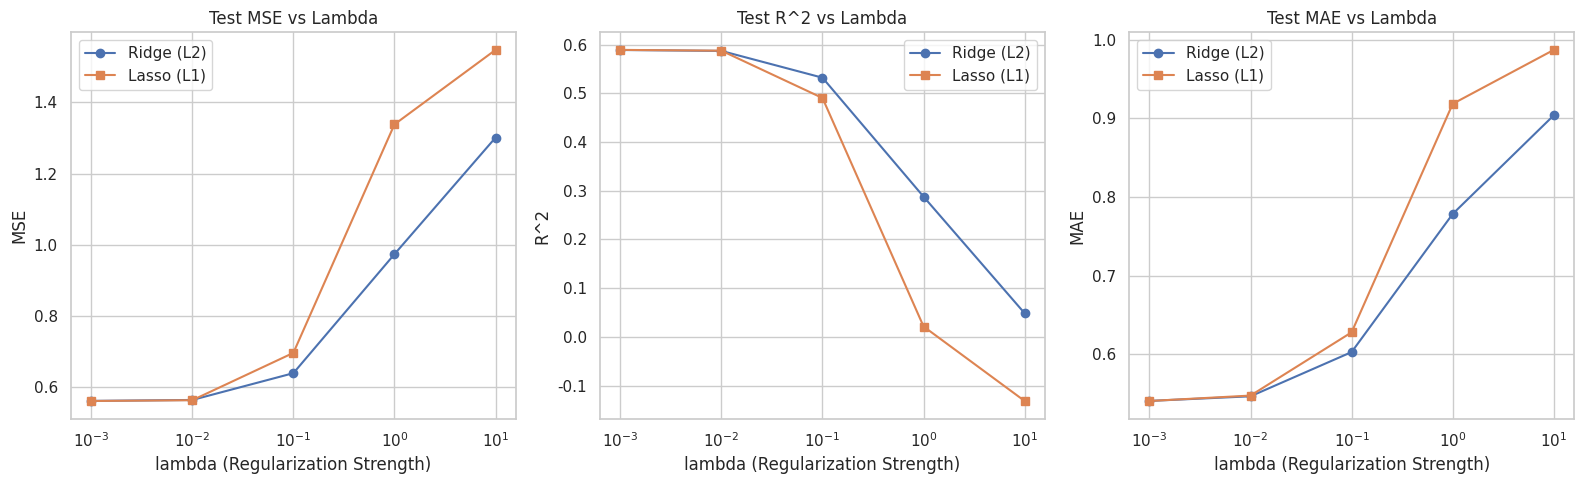

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE
axes[0].plot(lam_values, [ridge_results[l]['mse'] for l in lam_values], 'o-', label='Ridge (L2)')
axes[0].plot(lam_values, [lasso_results[l]['mse'] for l in lam_values], 's-', label='Lasso (L1)')
axes[0].set_xscale('log')
axes[0].set_xlabel('lambda (Regularization Strength)')
axes[0].set_ylabel('MSE')
axes[0].set_title('Test MSE vs Lambda')
axes[0].legend()

# R^2
axes[1].plot(lam_values, [ridge_results[l]['r2'] for l in lam_values], 'o-', label='Ridge (L2)')
axes[1].plot(lam_values, [lasso_results[l]['r2'] for l in lam_values], 's-', label='Lasso (L1)')
axes[1].set_xscale('log')
axes[1].set_xlabel('lambda (Regularization Strength)')
axes[1].set_ylabel('R^2')
axes[1].set_title('Test R^2 vs Lambda')
axes[1].legend()

# MAE
axes[2].plot(lam_values, [ridge_results[l]['mae'] for l in lam_values], 'o-', label='Ridge (L2)')
axes[2].plot(lam_values, [lasso_results[l]['mae'] for l in lam_values], 's-', label='Lasso (L1)')
axes[2].set_xscale('log')
axes[2].set_xlabel('lambda (Regularization Strength)')
axes[2].set_ylabel('MAE')
axes[2].set_title('Test MAE vs Lambda')
axes[2].legend()

plt.tight_layout()
plt.savefig('/tmp/regularization_effect.png', dpi=150)
plt.show()

### 6.2 L1 vs L2 特征权重对比

l2 在第 837 轮收敛


l1 在第 2405 轮收敛


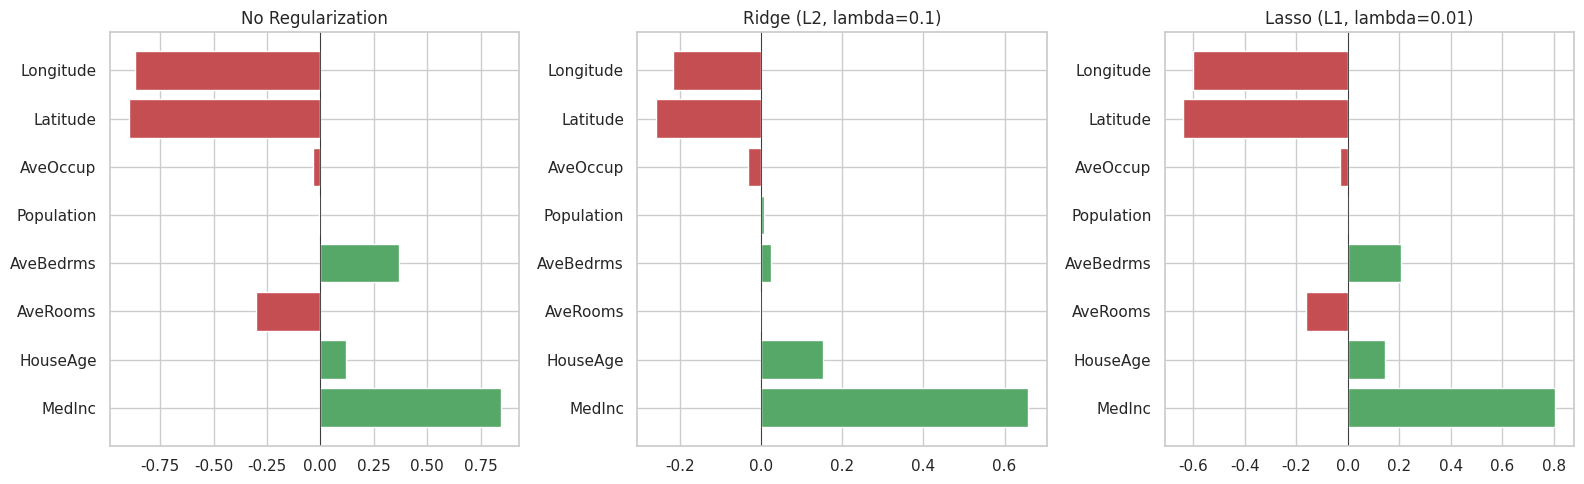

Lasso 非零特征数: 8 / 8


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 无正则化权重
from sklearn.linear_model import LinearRegression as SklearnLR
sk_lr = SklearnLR()
sk_lr.fit(X_train[:, 1:], y_train)

# Ridge (lambda=0.1)
ridge_best = RegularizedLinearRegression(penalty='l2', lam=0.1)
ridge_best.fit(X_train, y_train)

# Lasso (lambda=0.01)
lasso_best = RegularizedLinearRegression(penalty='l1', lam=0.01)
lasso_best.fit(X_train, y_train)

x_pos = range(len(feature_names))

axes[0].barh(x_pos, sk_lr.coef_.flatten(), color=['g' if w > 0 else 'r' for w in sk_lr.coef_.flatten()])
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(feature_names)
axes[0].set_title('No Regularization')
axes[0].axvline(x=0, color='black', linewidth=0.5)

axes[1].barh(x_pos, ridge_best.theta[1:].flatten(), color=['g' if w > 0 else 'r' for w in ridge_best.theta[1:].flatten()])
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(feature_names)
axes[1].set_title('Ridge (L2, lambda=0.1)')
axes[1].axvline(x=0, color='black', linewidth=0.5)

axes[2].barh(x_pos, lasso_best.theta[1:].flatten(), color=['g' if w > 0 else 'r' for w in lasso_best.theta[1:].flatten()])
axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(feature_names)
axes[2].set_title('Lasso (L1, lambda=0.01)')
axes[2].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('/tmp/weight_comparison.png', dpi=150)
plt.show()

print('Lasso 非零特征数:', np.sum(np.abs(lasso_best.theta[1:]) > 1e-4), '/', len(feature_names))

### 6.3 梯度下降收敛对比

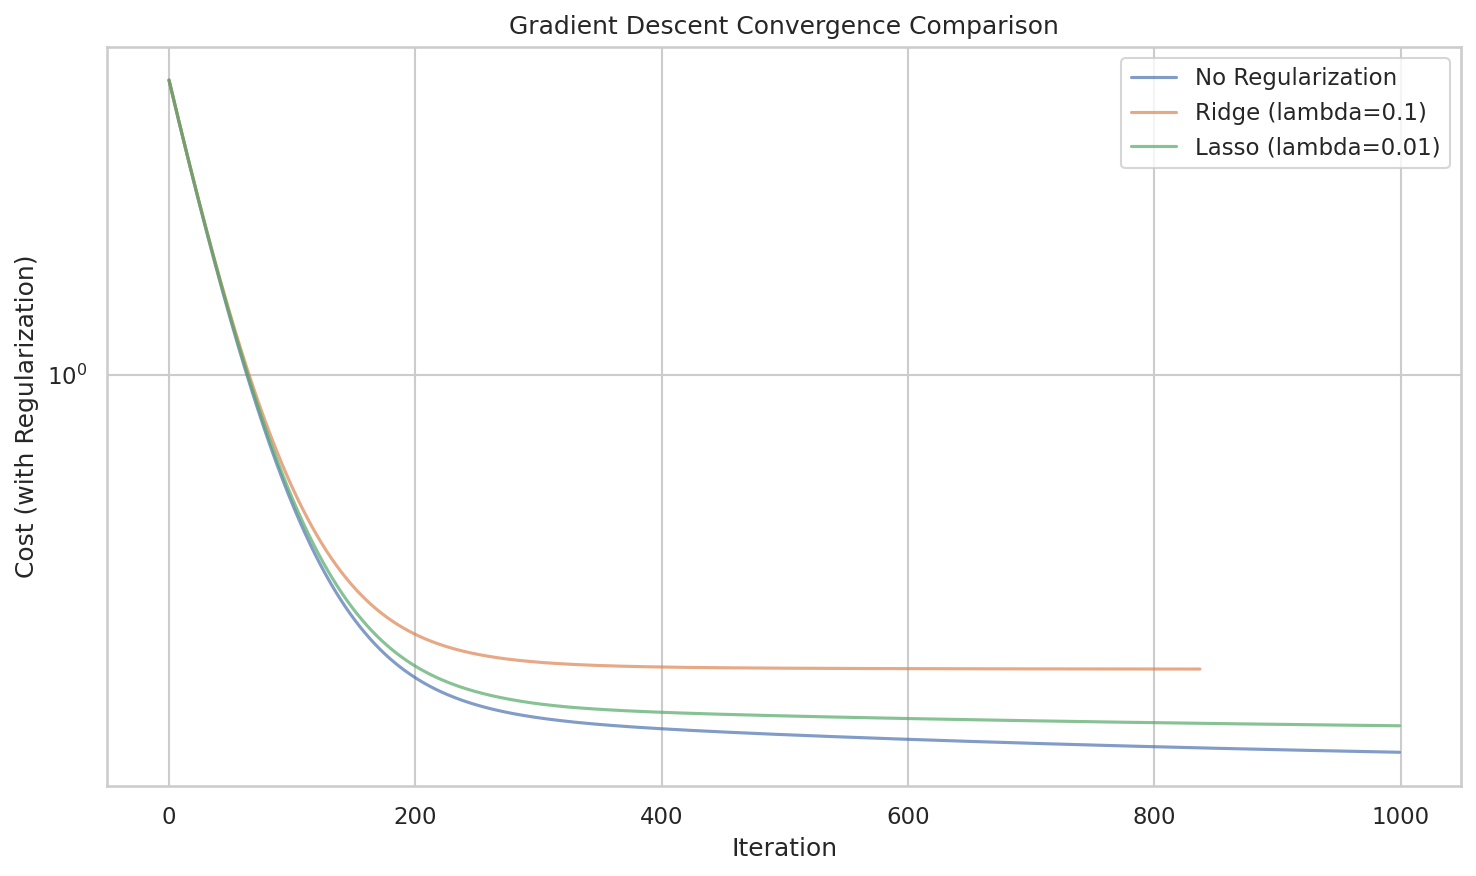

In [10]:
plt.figure(figsize=(10, 6), dpi=150)

# 无正则化
from sklearn.linear_model import SGDRegressor
lr_gd = RegularizedLinearRegression(penalty='l2', lam=0.0, lr=0.01, max_iter=1000)
lr_gd.fit(X_train, y_train)
plt.plot(lr_gd.cost_history, label='No Regularization', alpha=0.7)

# Ridge
plt.plot(ridge_best.cost_history[:len(lr_gd.cost_history)], label=f'Ridge (lambda={ridge_best.lam})', alpha=0.7)

# Lasso
plt.plot(lasso_best.cost_history[:len(lr_gd.cost_history)], label=f'Lasso (lambda={lasso_best.lam})', alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Cost (with Regularization)')
plt.title('Gradient Descent Convergence Comparison')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig('/tmp/convergence_comparison.png', dpi=150)
plt.show()

## 7. 结果汇总

In [11]:
print('='*60)
print('加州房价预测 — 正则化回归结果汇总')
print('='*60)
print(f'{"Method":<20} {"MSE":<12} {"R^2":<8} {"MAE":<8} {"非零特征":<8}')
print('-'*60)

# Ridge 最佳
best_ridge = ridge_results[0.1]
print(f'{"Ridge (lambda=0.1)":<20} {best_ridge["mse"]:<12.6f} {best_ridge["r2"]:<8.4f} {best_ridge["mae"]:<8.4f} {"N/A":<8}')

# Lasso 最佳
best_lasso = lasso_results[0.01]
print(f'{"Lasso (lambda=0.01)":<20} {best_lasso["mse"]:<12.6f} {best_lasso["r2"]:<8.4f} {best_lasso["mae"]:<8.4f} {str(best_lasso["non_zero"]):<8}')

# Elastic Net
print(f'{"ElasticNet":<20} {mean_squared_error(y_test, y_pred_elastic):<12.6f} '
      f'{elastic.score(X_test, y_test):<8.4f} {mean_absolute_error(y_test, y_pred_elastic):<8.4f} '
      f'{str(np.sum(np.abs(elastic.theta[1:]) > 1e-4)):<8}')

print('-'*60)
print()
print('结论:')
print('1. Ridge (L2) 和 Lasso (L1) 正则化均能有效控制模型复杂度')
print('2. L1 正则化具有特征选择能力，可将不重要特征的权重压缩为0')
print('3. L2 正则化倾向于让所有权重趋向于小而接近0的值，但不会精确为0')
print('4. ElasticNet 结合了 L1 和 L2 的优点')

加州房价预测 — 正则化回归结果汇总
Method               MSE          R^2      MAE      非零特征    
------------------------------------------------------------
Ridge (lambda=0.1)   0.640094     0.5319   0.6027   N/A     
Lasso (lambda=0.01)  0.564220     0.5874   0.5473   8       
ElasticNet           0.681550     0.5016   0.6143   8       
------------------------------------------------------------

结论:
1. Ridge (L2) 和 Lasso (L1) 正则化均能有效控制模型复杂度
2. L1 正则化具有特征选择能力，可将不重要特征的权重压缩为0
3. L2 正则化倾向于让所有权重趋向于小而接近0的值，但不会精确为0
4. ElasticNet 结合了 L1 和 L2 的优点
